First few basic classes will be introduced

## Basic classes

In [1]:
# Python standard libraries
import uuid     # Generally used for generating ids
import random   
import math     

In [2]:
class Position2D():
    '''Class used to keep track of 2D positions in cartesian coordinates'''
    def __init__(self, x: float, y: float):
        self.x = x      # X coordinate of the position
        self.y = y      # Y coordinate of the position

    def __add__(self, other: 'Position2D') -> 'Position2D':
        '''Add two Position2D objects'''
        if not isinstance(other, Position2D):
            raise ValueError("Can only add Position2D to Position2D")
        return Position2D(self.x + other.x, self.y + other.y)
    
    def __sub__(self, other: 'Position2D') -> 'Position2D':
        '''Subtract two Position2D objects'''
        if not isinstance(other, Position2D):
            raise ValueError("Can only subtract Position2D from Position2D")
        return Position2D(self.x - other.x, self.y - other.y)
    
    def __mul__(self, scalar: float) -> 'Position2D':
        '''Multiply the Position2D by a scalar'''
        if not isinstance(scalar, (int, float)):
            raise ValueError("Can only multiply Position2D by a scalar")
        return Position2D(self.x * scalar, self.y * scalar)
    
    def scale(self, scalar: float) -> None:
        '''Scale the Position2D by a scalar'''
        self.x = self.x * scalar
        self.y = self.y * scalar
    
    def randomNormalized(self) -> 'Position2D':
        '''Generate a random normalized Position2D'''
        angle = random.uniform(0, 2 * math.pi)
        return Position2D(math.cos(angle), math.sin(angle))

def distance_to(A: Position2D, B: Position2D) -> float:
    '''Calculate the Euclidean distance to another Position2D'''
    return ((A.x - B.x) ** 2 + (A.y - B.y) ** 2) ** 0.5

def direction_to(from_point: Position2D, to_point: Position2D) -> Position2D:
    '''Get normalized direction "Vector"'''
    point = to_point - from_point
    magnitude = distance_to(point, Position2D(0,0))
    return point * (1/magnitude)

### Abstract Agent, Task and Environment classes

In [3]:
from abc import ABC, abstractmethod
from asyncio import Task
from enum import Enum, auto

class Agent(ABC):
    '''Abstract base class for agents in a 2D environment'''
    def __init__(self, position: Position2D, task_radius: int, com_radius: int, velocity: int):
        # User parameters
        self._id = uuid.uuid4()                 # Unique identifier for the agent
        self.position = position                # Current position of the agent
        self.com_radius = com_radius            # Communication radius of the agent
        self.task_radius = task_radius          # Task radius of the agent
        self.velocity = velocity                # Velocity of the agent

        # Inner parameters
        self._state = AgentState.MOVING     # Needed for inner state machine
        self._sensorTask = None             # A readout of task signal
        self._sensorCom = None              # A readout of communication signal

    @abstractmethod
    def move(self):
        '''Move the agent to a new position'''
        pass
    
    @abstractmethod
    def writeTaskSensor(self, value: float, task) -> None:
        '''Function to pass information from the environment'''
        pass

    @abstractmethod
    def writeComSensor(self, agent: 'Agent', distance: float) -> None:
        '''Function to pass information from other agents in the environment'''
        pass

    @abstractmethod
    def decide(self) -> None:
        '''Should be called in every iteration -- bascially an implementation of agent behaviour'''
        pass
    
    @abstractmethod
    def taskComplete(self) -> None:
        '''Function to notify the agent that a task has been completed'''
        pass

class AgentState(Enum):
    '''Enumeration for agent states'''
    MOVING = auto()       # Agent is moving
    CALL_OUT = auto()     # Agent detected a task and should inform other agents
    WAITING = auto()      # Agent is waiting for a task to be completed
    RESPONDING = auto()   # Agent received a call-out and tries to find the calling agent

In [4]:
class Task():
    '''Class to represent a task in the environment'''
    def __init__(self, position: Position2D, capacity: int):
        self._id = uuid.uuid4()      # Unique identifier for the task
        self.position = position    # Position of the task in the environment
        self.agents = dict()        # Dict of agents currently in the task_radius = [agent._id] = agent_obj
        self.completed = False      # Boolean indicating if the task has been completed
        self.capacity = capacity    # Amount of agents needed to complete the task

    def add_agent(self, agent: Agent) -> None:
        '''Update the task status based on the number of agents in its radius'''
        self.agents[agent._id] = agent
        if len(self.agents) >= self.capacity:
            self.completed = True

    def remove_agent(self, agent: Agent) -> None:
        '''Remove an agent from the task's agent list'''
        self.agents.pop(agent._id, None)


    def respawn(self, position: Position2D) -> None:
        '''Respawn the task at a new position'''
        self._id = uuid.uuid4()      # Regenerate UUID
        self.position = position
        self.agents = dict()
        self.completed = False

In [5]:
import random


class Environment():
    '''Class for managing agent environment'''
    def __init__(self, size: tuple[int, int], task_count: int, task_capacity: int, task_radius: int, agent_radius: int, agent_count: int, agent_class):
        
        # Environment parameters
        # =============================================================================================
        self.width = size[0]                        # Width of the rectangular 2D environment
        self.height = size[1]                       # Height of the rectangular 2D environment
        self._keepHistory = False                   # Whether to keep history of the environment state

        # Task parameters
        # =============================================================================================
        self.task_count = task_count                # Number of tasks in the environment
        self.task_capacity = task_capacity          # Amount of agents needed in task_radius to complete a task
        self.task_radius = task_radius              # Radius of each task's area of effect
        
        # Agent parameters
        # =============================================================================================
        self.agent_radius = agent_radius            # Radius of the agent communication area
        self.agent_count = agent_count              # Number of agents in the environment
        self.agent = agent_class                    # Class of agents in the environment - must be a subclass of Agent

        # Environment state
        # =============================================================================================
        self.tasks = dict()                                         # Dict of tasks in the environment [task._id] = task_obj
        self.agents = dict()                                        # Dict of agents in the environment [agent._id] = agent_obj
        self.tasks_done = dict()                                    # Keeps track of UUIDs of done tasks and agents UUIDs that completed them
        self.iteration = 0                                          # Current iteration of the environment
        self.history = {"agents": dict(), "tasks": dict()}          # History of the environment state (if needed)

    def initialize(self) -> None:
        '''Initialize the environment with tasks and agents'''

        # Reset agent and task dicts
        self.tasks = dict()
        self.agents = dict()

        # Create tasks
        for _ in range(self.task_count):
            x = random.uniform(0, self.width)
            y = random.uniform(0, self.height)
            task: Task = Task(Position2D(x, y), self.task_capacity)
            self.tasks[task._id] = task
        
        # Create agents
        for _ in range(self.agent_count):
            x = random.uniform(0, self.width)
            y = random.uniform(0, self.height)
            agent: Agent = self.agent(Position2D(x, y))
            self.agents[agent._id] = agent

        # Zero the counters        
        self.tasks_done = dict()
        self.history = {"agents": dict(), "tasks": dict()} 
        self._keepHistory = False
        self.iteration = 0

    def update_taskSensors(self) -> list:
        '''Updates readings of the task signals in agent sensors, returns a list of agents that are in the task radii and can communicate'''
        agentsList = dict()     # This will be used to narrow down the communication search later on

        for agentKey in self.agents:
            for taskKey in self.tasks:
                agent = self.agents[agentKey]
                task = self.tasks[taskKey]

                # Calculate distance
                dist = distance_to(agent.position, task.position)
                if dist <= self.task_radius:
                    task.add_agent(agent)
                    if task._id not in agentsList:
                        agentsList[task._id] = list()
                    agentsList[task._id].append(agent._id)

                # Before updating the sensor, we check if the task is already completed
                if task.completed == False:
                    agent.writeTaskSensor(dist, task)
                    continue

                # If the task is completed, we skip updating the sensor -- otherwise the agent might think it can still contribute
                self.tasks_done[task._id] = {"agents": list(task.agents.keys()), "iteration": self.iteration, "position": task.position}

                # Additionally we pop the agents from the contribution list
                agentsList.pop(task._id, None)
                task.respawn(Position2D(random.uniform(0, self.width), random.uniform(0, self.height)))    # Now new task needs to be spawned
                
                if self._keepHistory == True:
                    if task._id not in self.history["tasks"]:
                        self.history["tasks"][task._id] = dict()
                    self.history["tasks"][task._id]["position"] = task.position

                for a_id in task.agents:
                    a = task.agents[a_id]
                    a.taskComplete()   # Notify agents that the task is complete

        # Finally construct a list of agents
        agents = list()
        for taskKey in agentsList:
            for agent_id in agentsList[taskKey]:
                if agent_id not in agents:
                    agents.append(agent_id)

        return agents

    def update_communicationSensors(self, agentsList: list[Agent]) -> None:
        '''Updates readings of the communication signals in agent sensors'''
        for agentKey in agentsList:
            for otherKey in self.agents:
                agent = self.agents[agentKey]
                otherAgent = self.agents[otherKey]
                if agent._id == otherAgent._id:
                    # Skip self
                    continue
                
                # Communication only happens between agents that are in the com radius
                dist = distance_to(agent.position, otherAgent.position)
                if dist <= agent.com_radius:
                    if agent._state is AgentState.CALL_OUT:
                        otherAgent.writeComSensor(agent, dist)

    def run(self, iterations: int, keep_history: bool = False) -> None:
        '''Run the environment for a specified number of iterations'''
        self.initialize()

        # Prepare history
        self._keepHistory = keep_history
        if self._keepHistory == True:
            # Add tasks to history
            for taskKey in self.tasks:
                task = self.tasks[taskKey]
                self.history["tasks"][task._id] = dict()
                self.history["tasks"]["capacity"] = self.task_capacity
                self.history["tasks"]["radius"] = self.task_radius
                self.history["tasks"][task._id]['position'] = task.position

        for _ in range(iterations):
            # First we update sensors and tasks
            agentList = self.update_taskSensors()
            self.update_communicationSensors(agentList)

            # Then we let agents decide
            for agentKey in self.agents:
                agent = self.agents[agentKey]
                agent.decide()

                # Archive
                if self._keepHistory == True:
                    if agent._id not in self.history["agents"]:
                        self.history["agents"][agent._id] = dict()

                    if 'position' not in self.history["agents"][agent._id]:
                        self.history["agents"][agent._id]['position'] = list()
                    self.history["agents"][agent._id]['position'].append(agent.position)
                    self.history["agents"][agent._id]['state'] = agent._state.name

            self.iteration += 1
            

    def test_run(self):
        '''Run a simple test of the environment'''
        self.initialize()
        position =  [list(), list()]
        for _ in range(1000):
            self.iteration += 1
            #print(f"Iteration: {self.iteration}")
            for agent in self.agents:
                agent.move()
                position[0].append(agent.position.x)
                position[1].append(agent.position.y)
                #print(f"Agent {agent._id} moved to position ({agent.position.x}, {agent.position.y})")

        return position[0], position[1]

    def __repr__(self) -> str:
        return f"Environment(width={self.width}, height={self.height}, task_count={self.task_count}, task_capacity={self.task_capacity}, task_radius={self.task_radius}, agent_radius={self.agent_radius})"



### SimulatorRunner class
Class genereted by AI

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import itertools # Used for systematically creating parameter combinations

class SimulationRunner:
    """
    A refactored, flexible helper class to manage running, analyzing, and 
    plotting simulation experiments using a generic sweep-and-plot approach.
    """
    def __init__(self, environment_class, agent_init_func, base_params: dict):
        self.environment_class = environment_class
        self.agent_init_func = agent_init_func
        self.base_params = base_params
        self.results = pd.DataFrame() # Results are now stored in a pandas DataFrame

    def _run_single_simulation(self, iterations: int, params: dict) -> float:
        """(Internal) Runs one simulation and returns the performance score."""
        env = self.environment_class(
            size=params['ENV_SIZE'],
            task_count=params['task_count'],
            task_capacity=params['task_capacity'],
            task_radius=params['task_radius'],
            agent_radius=params['agent_radius'],
            agent_count=params['agent_count'],
            agent_class=lambda pos: self.agent_init_func(pos, velocity=params['velocity'])
        )
        env.run(iterations)
        return len(env.tasks_done) / iterations if iterations > 0 else 0

    # --------------------------------------------------------------------
    # CORE METHOD: A SINGLE, POWERFUL FUNCTION TO RUN ALL EXPERIMENTS
    # --------------------------------------------------------------------
    def run_sweep(self, sweep_params: dict, replications: int, description: str = "Running Sweep"):
        """
        Runs a generic parameter sweep for all combinations of given parameters.

        Args:
            sweep_params (dict): A dictionary where keys are parameter names and
                                 values are lists of values to test.
                                 e.g., {'agent_count': [5, 10], 'iterations': [1000, 2000]}
            replications (int): The number of times to run each unique parameter combination.
            description (str): A description for the progress bar.
        """
        print(f"--- Starting Parameter Sweep: {description} ---")
        
        # Generate all unique combinations of parameters
        param_names = list(sweep_params.keys())
        param_values = list(sweep_params.values())
        param_combinations = list(itertools.product(*param_values))
        
        all_results = []
        
        with tqdm(total=len(param_combinations) * replications, desc=description) as pbar:
            for combo in param_combinations:
                current_params = self.base_params.copy()
                
                # Create a dictionary for the current combination
                run_config = {}
                for i, name in enumerate(param_names):
                    current_params[name] = combo[i]
                    run_config[name] = combo[i]
                
                # Run the simulation 'replications' times for this combination
                for rep in range(replications):
                    score = self._run_single_simulation(current_params.get('iterations', 1), current_params)
                    result_row = run_config.copy()
                    result_row['replication'] = rep
                    result_row['score'] = score
                    all_results.append(result_row)
                    pbar.update(1)

        self.results = pd.DataFrame(all_results)
        print("--- Sweep Finished ---")

    # --------------------------------------------------------------------
    # CORE METHOD: A SINGLE, POWERFUL FUNCTION TO PLOT ALL RESULTS
    # --------------------------------------------------------------------
    def plot(self, x_axis: str, series: str = None, title: str = None):
        """
        Generates a plot from the stored results.

        Args:
            x_axis (str): The name of the parameter to use for the x-axis.
            series (str, optional): The name of the parameter to use for creating
                                    different lines (series) on the plot. Defaults to None.
            title (str, optional): The title of the plot. Defaults to an auto-generated title.
        """
        if self.results.empty:
            print("No results to plot. Please run an experiment first.")
            return

        plt.figure(figsize=(12, 8))
        
        # Group by the series and x-axis parameters to calculate stats
        group_by_params = [series, x_axis] if series else [x_axis]
        stats = self.results.groupby(group_by_params)['score'].agg(['mean', 'std']).reset_index()

        if series:
            # Plot each series as a separate line with an error bar
            for name, group in stats.groupby(series):
                plt.errorbar(group[x_axis], group['mean'],
                             fmt='-o', capsize=5, label=f"{series.replace('_', ' ').title()} = {name}")
            plt.legend()
        else:
            # Plot a single line with an error bar
            plt.errorbar(stats[x_axis], stats['mean'], fmt='-o', capsize=5)

        # Formatting
        plt.xlabel(x_axis.replace('_', ' ').title())
        plt.ylabel("Average Score (Tasks / Iteration)")
        if not title:
            title = f"System Performance vs. {x_axis.replace('_', ' ').title()}"
            if series:
                title += f" by {series.replace('_', ' ').title()}"
        plt.title(title)
        plt.grid(True)
        plt.show()

    # --------------------------------------------------------------------
    # CONVENIENCE WRAPPERS (Old functions now call the core methods)
    # --------------------------------------------------------------------
    def run_experiment(self, parameter_to_vary: str, parameter_values: list, iterations: int, replications: int):
        """Convenience wrapper for a simple 1D parameter sweep."""
        sweep_params = {
            parameter_to_vary: parameter_values,
            'iterations': [iterations] # Iterations is fixed
        }
        self.run_sweep(sweep_params, replications, f"Varying '{parameter_to_vary}'")
        self.plot(x_axis=parameter_to_vary)

    def run_iteration_experiment(self, iteration_values: list, replications: int):
        """Convenience wrapper to see performance vs. simulation length."""
        sweep_params = {'iterations': iteration_values}
        self.run_sweep(sweep_params, replications, "Testing Iteration Lengths")
        self.plot(x_axis='iterations')

    def run_parameter_sweep_over_iterations(self, parameter_to_vary: str, parameter_values: list, iteration_values: list, replications: int):
        """Convenience wrapper for a 2D parameter sweep."""
        sweep_params = {
            parameter_to_vary: parameter_values,
            'iterations': iteration_values
        }
        self.run_sweep(sweep_params, replications, f"Sweeping '{parameter_to_vary}' vs. Iterations")
        self.plot(x_axis='iterations', series=parameter_to_vary)

    def visualize_single_run(self, iterations: int, vis_params: dict = None):
        """
        Runs a single simulation with history tracking and plots the agent trajectories.

        Args:
            iterations (int): The number of iterations to run the simulation for.
            vis_params (dict, optional): A dictionary of specific parameters for this run.
                                         If None, uses the runner's base_params.
        """
        print("--- Starting Single Run for Visualization ---")
        
        # Use specific parameters for this run, or the base ones if none are given
        if vis_params is None:
            vis_params = self.base_params
        
        # Create a dedicated environment for this visualization run
        env = self.environment_class(
            size=vis_params['ENV_SIZE'],
            task_count=vis_params['task_count'],
            task_capacity=vis_params['task_capacity'],
            task_radius=vis_params['task_radius'],
            agent_radius=vis_params['agent_radius'],
            agent_count=vis_params['agent_count'],
            agent_class=lambda pos: self.agent_init_func(pos, velocity=vis_params['velocity'])
        )
        
        # Run the simulation with history tracking enabled
        env.run(iterations, keep_history=True)
        print("--- Simulation Finished, Generating Plot ---")

        # --- Plotting Logic (from your provided code) ---
        plt.figure(figsize=(10, 10))
        
        # Plot agent trajectories from env.history
        for agent_id, agent_hist in env.history["agents"].items():
            if 'position' in agent_hist:
                x = [pos.x for pos in agent_hist['position']]
                y = [pos.y for pos in agent_hist['position']]
                plt.plot(x, y, label=f'Agent {str(agent_id)[:8]}', alpha=0.8)

        # Plot task positions and radii from env.history
        # This will plot both the initial and all respawned task locations
        task_radius_val = env.task_radius # Use the definitive value from the env
        plotted_task_labels = set()

        for task_id, task_hist in env.history["tasks"].items():
            if isinstance(task_hist, dict) and 'position' in task_hist:
                pos = task_hist['position']
                label = f'Task Location'
                if label not in plotted_task_labels:
                    plt.scatter(pos.x, pos.y, c='red', marker='*', s=200, label=label)
                    plotted_task_labels.add(label)
                else:
                    plt.scatter(pos.x, pos.y, c='red', marker='*', s=200)
                
                # Draw task radius as a circle
                circle = plt.Circle((pos.x, pos.y), task_radius_val, color='red', fill=False, linestyle='--', alpha=0.4)
                plt.gca().add_patch(circle)

        plt.xlabel('X position')
        plt.ylabel('Y position')
        plt.title(f'Agent Trajectories and Task Locations ({iterations} Iterations)')
        
        # To avoid clutter, only show a limited number of agent labels in the legend
        handles, labels = plt.gca().get_legend_handles_labels()
        # Display task labels + up to 5 agent labels
        plt.legend(handles[:6], labels[:6])
        
        plt.grid(True)
        plt.axis('equal')
        plt.xlim(0, vis_params['ENV_SIZE'][0])
        plt.ylim(0, vis_params['ENV_SIZE'][1])
        plt.show()

## Simple agent implementation -- Questions A-D

In [14]:
class SimpleAgent(Agent):
    '''A simple agent that moves randomly within the environment'''
    def __init__(self, position: Position2D, env_size: tuple[int, int], task_radius:int, com_radius: int, velocity: int):
        super().__init__(position, task_radius, com_radius, velocity) 
        self._boundary = env_size

    def move(self):
        '''Move the agent to a new position -- perform random walk'''
        velocity_vector = Position2D(0, 0).randomNormalized()   
        velocity_vector.scale(self.velocity)
        new_position = self.position + velocity_vector 

        # Check for boundary collisions
        if 0 <= new_position.x <= self._boundary[0] and 0 <= new_position.y <= self._boundary[1]:
            self.position = new_position
        else:
            # If out of bounds then agent should:
            # 1. Move to the boundary
            # 2. "Reroll" movement 
            # 3. Go rest of the distance within bounds
            first_scale = 1.0
            dist_x, dist_y = 0, 0

            # The movement after the boundary hit
            second_movement = Position2D(0, 0).randomNormalized()
            second_movement.scale(self.velocity)    # So this operation isn't forgotten along the way

            # First it is needed to check which boundary is hit, and how much distance is left to it
            # At the same time the second_movement will be modified so it won't be out of bounds -- this behaviour can be imagined as turning 180 and picking some new angle from <-90, 90>
            
            # Even though for simplification, the check is done by assuming that the agent knows where it is in real implementation it would not be necessary,
            # In reality it would be enough to give the robotic agent cheap sensor such as ultrasound sensor and set some tresholding 
            # So in this implementation it is assumed that the dist_x, dist_y can be yielded from sensor outputs
            if new_position.x < 0:
                dist_x = -self.position.x
                second_movement.x = abs(second_movement.x)
            elif new_position.x > self._boundary[0]:
                dist_x = self._boundary[0] - self.position.x
                second_movement.x = -abs(second_movement.x)
            elif new_position.y < 0:
                dist_y = -self.position.y
                second_movement.y = abs(second_movement.y)
            elif new_position.y > self._boundary[1]:
                dist_y = self._boundary[1] - self.position.y
                second_movement.y = -abs(second_movement.y)
            
            # Now the movement should be capped to the closest boundary
            if abs(dist_x) >= abs(dist_y):
                first_scale = abs(dist_y / velocity_vector.y) if velocity_vector.y != 0 else 0
            else:
                first_scale = abs(dist_x / velocity_vector.x) if velocity_vector.x != 0 else 0
            
            # Rescale
            velocity_vector.scale(first_scale)
            second_movement.scale(1.0 - first_scale)

            # Final position
            self.position = self.position + velocity_vector + second_movement

    def decide(self):
        '''Update the agent's state and perform actions based on its state'''
        # This agent doesn't communicate with other agents and has two states -- waiting and moving
        
        if self._state is AgentState.WAITING:
            # When the agent is in the task area it waits for task completion -- there is no mechanism to prevent "infinite" time, but it's a concious choice
            return
        elif self._state is AgentState.MOVING:
            # When the agent is moving it waits for signal "strong enough" to decide that it's in task area -- obviously on hardware this could be implemented in many ways but for this task it's gonna be assumed that the signal = distance from the task

            # First the sensor is checked
            if self._sensorTask is not None:
                if self._sensorTask <= self.task_radius:
                    # The agent is able to work on the task so stops moving
                    self._state = AgentState.WAITING
                    return
                
                self.move()
        
        else:
            raise ValueError(f"Agent {0} is in illegal state: {1}", self._id, self._state)

    def writeComSensor(self, agent: Agent, distance: float) -> None:
        '''This agent does not communicate with other agents'''
        pass

    def writeTaskSensor(self, value: float, task: Task) -> None:
        self._sensorTask = value
        # This agent is simple enough not to store data about the task

    def taskComplete(self) -> None:
        '''Notify the agent that the task it was working on has been completed'''
        self._state = AgentState.MOVING
        


### Question A

In [16]:
# Define the base parameters for your simulation
# These should be the default values for a standard run
base_parameters = {
    'ENV_SIZE': (1000, 1000),
    'task_count': 1,
    'task_capacity': 1,
    'task_radius': 50,
    'agent_radius': 50,
    'agent_count': 1,  # A default value
    'velocity': 25
}

# Modify your agentInit to accept velocity
def agentInit(pos, velocity):
    # This now correctly matches the call from within SimulationRunner
    return SimpleAgent(pos, base_parameters['ENV_SIZE'], base_parameters['task_radius'], base_parameters['agent_radius'], velocity)

# Create the runner instance
runner = SimulationRunner(Environment, agentInit, base_parameters)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


--- Starting Single Run for Visualization ---
--- Simulation Finished, Generating Plot ---


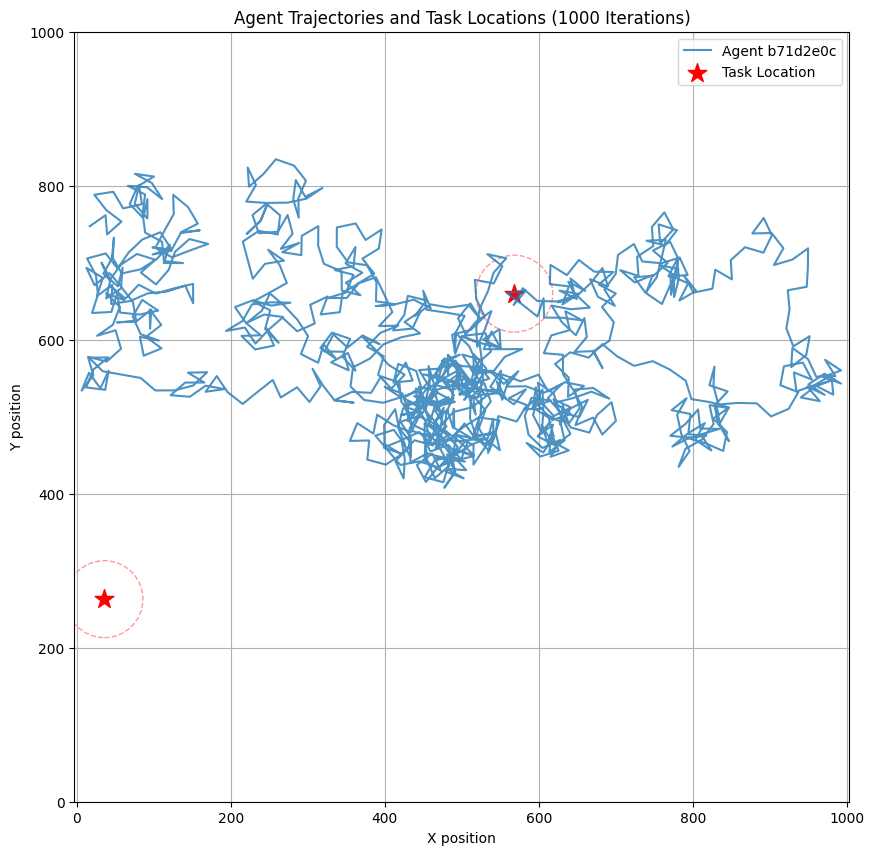

In [18]:

runner.visualize_single_run(
    iterations=1000,
    vis_params=base_parameters
)

### Question C

--- Starting Parameter Sweep: Running Sweep ---


Running Sweep: 100%|██████████| 1200/1200 [00:13<00:00, 87.43it/s]


--- Sweep Finished ---


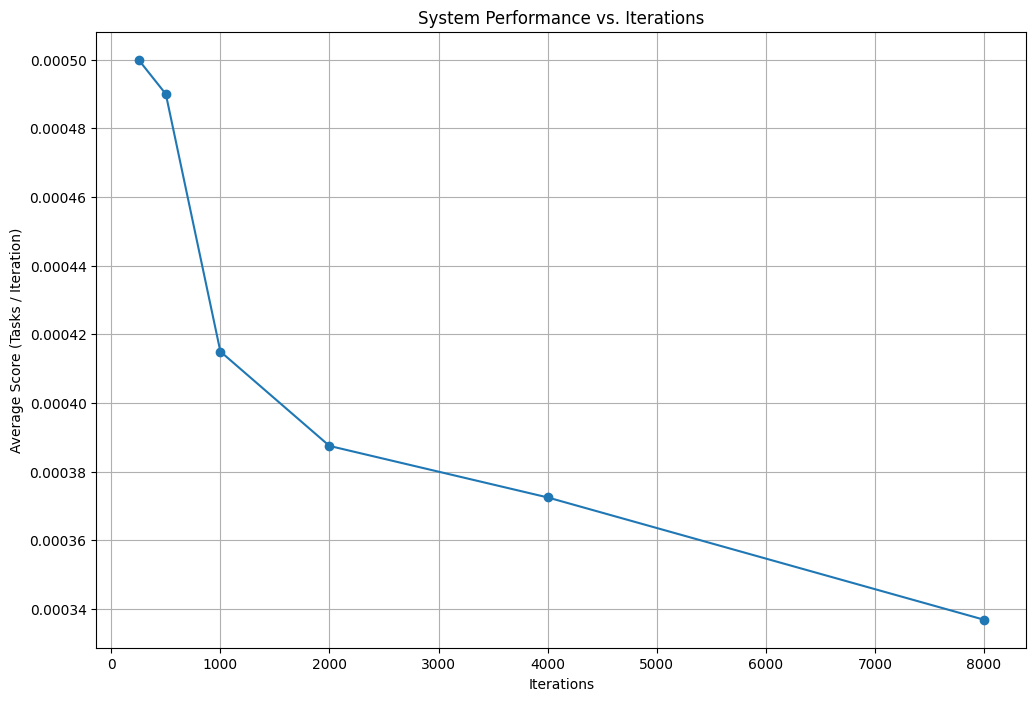

In [19]:
# Question 1c
stable_replications_to_use = 200 

sweep_parameters = {
    'agent_count': [1],
    'task_capacity': [1],
    'iterations': [250, 500, 1000, 2000, 4000, 8000] 
}

# 2. Run the sweep
runner.run_sweep(sweep_params=sweep_parameters, replications=200)

# 3. Plot the results
runner.plot(x_axis='iterations')

### Question B

--- Starting Parameter Sweep: Running Sweep ---


Running Sweep: 100%|██████████| 500/500 [02:02<00:00,  4.08it/s]


--- Sweep Finished ---


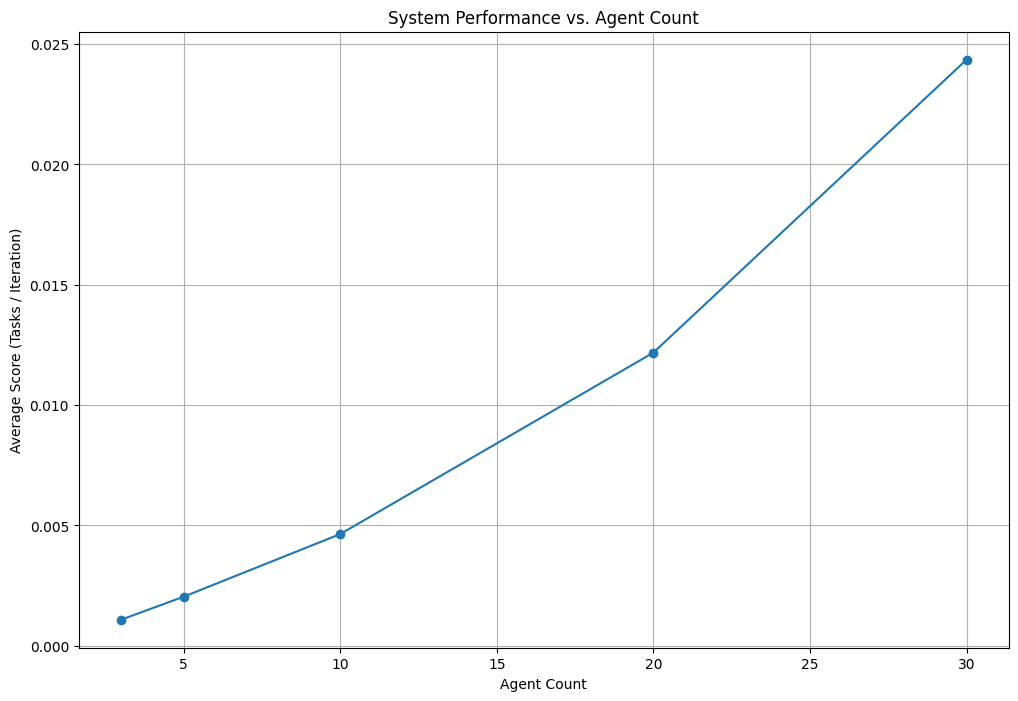

In [ ]:
# The number of runs for each data point
replications_for_sweep = 100

sweep_parameters = {
    'agent_count': [3, 5, 10, 20, 30],
    'task_count': [1],
    'task_radius': [50],
    'task_capacity': [1],
    'iterations': [4000] 
}

# 2. Run the sweep
runner.run_sweep(sweep_params=sweep_parameters, replications=replications_for_sweep)

# 3. Plot the results
runner.plot(x_axis='agent_count')

In [ ]:
# Question B -- additional 

# The number of runs for each data point
replications_for_sweep = 100

sweep_parameters = {
    'agent_count': [3, 5, 10, 20, 30],
    'task_count': [1],
    'task_radius': [50],
    'task_capacity': [1],
    'iterations': [500, 1000, 2000, 4000, 6000] 
}

# 2. Run the sweep
runner.run_sweep(sweep_params=sweep_parameters, replications=replications_for_sweep)

# 3. Plot the results
runner.plot(x_axis='iterations', series='agent_count')

--- Starting Parameter Sweep: Running Sweep ---


Running Sweep:  57%|█████▋    | 1437/2500 [01:34<04:44,  3.74it/s]

### Question C

--- Starting Parameter Sweep: Running Sweep ---


Running Sweep: 100%|██████████| 500/500 [02:11<00:00,  3.82it/s]

--- Sweep Finished ---


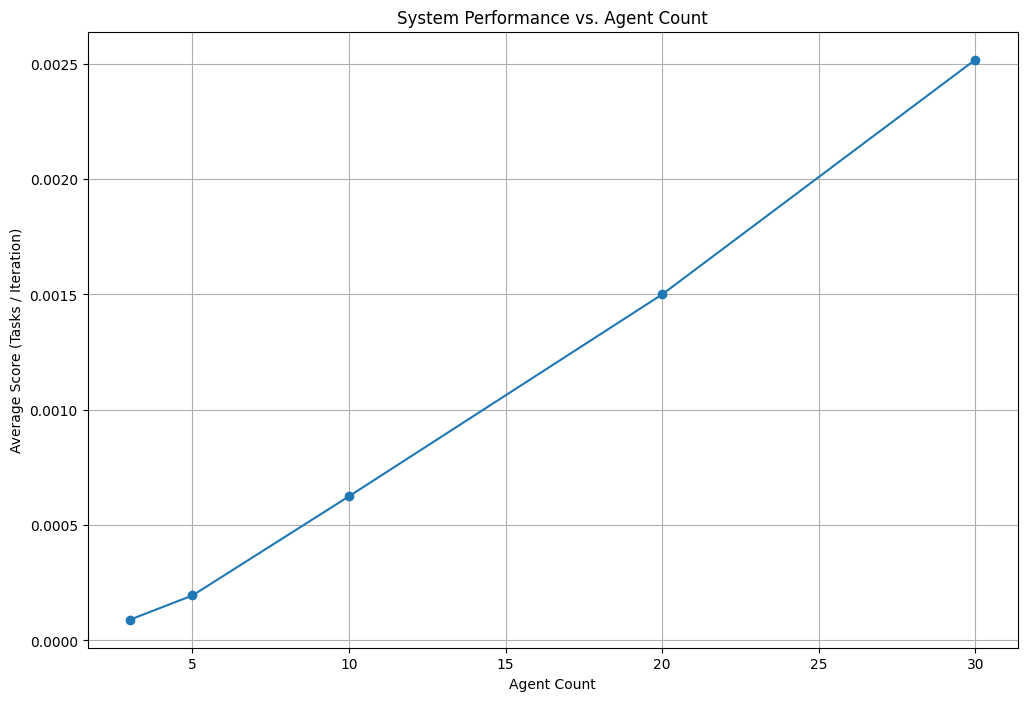

In [ ]:
# Question c
replications_for_sweep = 100

sweep_parameters = {
    'agent_count': [3, 5, 10, 20, 30],
    'task_capacity': [3],
    'task_count': [1],
    'task_radius': [50],
    'iterations': [4000] 
}

# 2. Run the sweep
runner.run_sweep(sweep_params=sweep_parameters, replications=replications_for_sweep)

# 3. Plot the results
runner.plot(x_axis='agent_count')

### Question D

--- Starting Parameter Sweep: Running Sweep ---


Running Sweep: 100%|██████████| 1500/1500 [22:03<00:00,  1.13it/s]


--- Sweep Finished ---


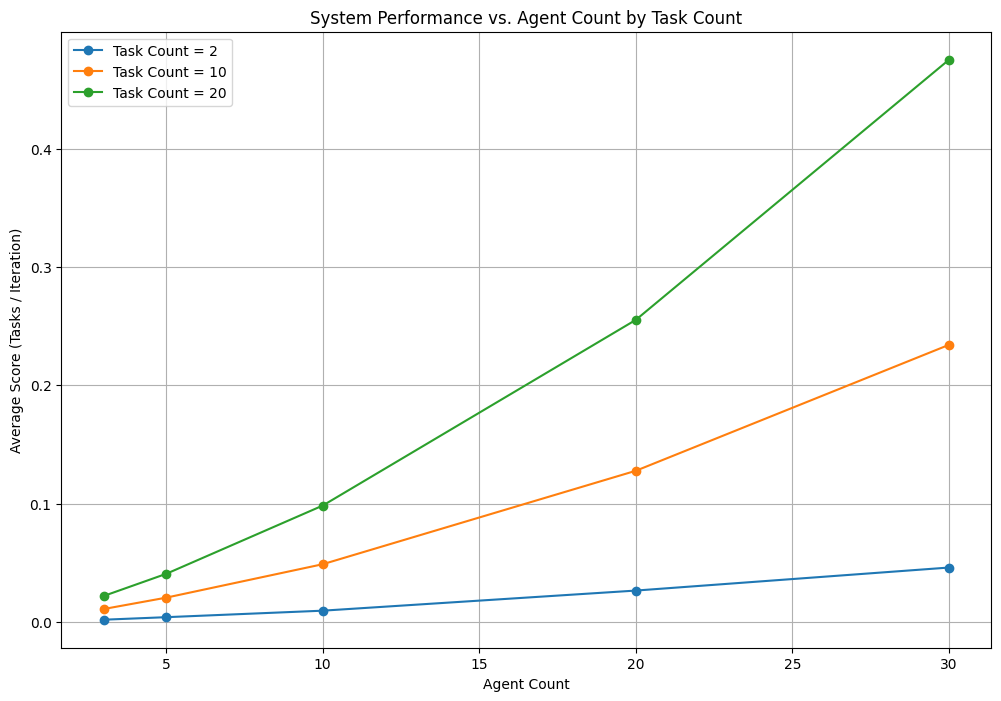

In [ ]:
# The number of runs for each data point
replications_for_sweep = 100

sweep_parameters = {
    'agent_count': [3, 5, 10, 20, 30],
    'task_count': [2, 10, 20],
    'task_capacity': [1],
    'iterations': [4000] 
}

# 2. Run the sweep
runner.run_sweep(sweep_params=sweep_parameters, replications=replications_for_sweep)

# 3. Plot the results
runner.plot(x_axis='agent_count', series='task_count')

## SocialAgent Implementation -- Question E

In [ ]:
class SocialAgent(Agent):
    '''A simple agent that moves randomly within the environment'''
    def __init__(self, position: Position2D, env_size: tuple[int, int], task_radius:int, com_radius: int, timeout_callout:int, timeout_respond: int, velocity: int):
        super().__init__(position, task_radius, com_radius, velocity)
        self.timeout_callout = timeout_callout      # How many iterations the agent should wait for help
        self.timeout_respond = timeout_respond      # How many iterations the agent should try to find callout caller
        self._boundary = env_size

        self._direction = Position2D(0,0)
        self._lastDistance = None
        self._waitingTime = 0                   # How long the agent has been waiting in the waiting state
        self._respondTime = 0                   # How long the agent has been trying to respond to callout

    def move(self):
        '''Move the agent to a new position -- perform random walk'''
        velocity_vector = Position2D(0, 0).randomNormalized()   
        velocity_vector.scale(self.velocity)
        new_position = self.position + velocity_vector 

        # Check for boundary collisions
        if 0 <= new_position.x <= self._boundary[0] and 0 <= new_position.y <= self._boundary[1]:
            self.position = new_position
        else:
            # If out of bounds then agent should:
            # 1. Move to the boundary
            # 2. "Reroll" movement 
            # 3. Go rest of the distance within bounds
            first_scale = 1.0
            dist_x, dist_y = 0, 0

            # The movement after the boundary hit
            second_movement = Position2D(0, 0).randomNormalized()
            second_movement.scale(self.velocity)    # So this operation isn't forgotten along the way

            # First it is needed to check which boundary is hit, and how much distance is left to it
            # At the same time the second_movement will be modified so it won't be out of bounds -- this behaviour can be imagined as turning 180 and picking some new angle from <-90, 90>
            
            # Even though for simplification, the check is done by assuming that the agent knows where it is in real implementation it would not be necessary,
            # In reality it would be enough to give the robotic agent cheap sensor such as ultrasound sensor and set some tresholding 
            # So in this implementation it is assumed that the dist_x, dist_y can be yielded from sensor outputs
            if new_position.x < 0:
                dist_x = -self.position.x
                second_movement.x = abs(second_movement.x)
            elif new_position.x > self._boundary[0]:
                dist_x = self._boundary[0] - self.position.x
                second_movement.x = -abs(second_movement.x)
            elif new_position.y < 0:
                dist_y = -self.position.y
                second_movement.y = abs(second_movement.y)
            elif new_position.y > self._boundary[1]:
                dist_y = self._boundary[1] - self.position.y
                second_movement.y = -abs(second_movement.y)
            
            # Now the movement should be capped to the closest boundary
            if abs(dist_x) >= abs(dist_y):
                first_scale = abs(dist_y / velocity_vector.y) if velocity_vector.y != 0 else 0
            else:
                first_scale = abs(dist_x / velocity_vector.x) if velocity_vector.x != 0 else 0
            
            # Rescale
            velocity_vector.scale(first_scale)
            second_movement.scale(1.0 - first_scale)

            # Final position
            self.position = self.position + velocity_vector + second_movement

    def moveDirection(self):
        '''Moves toward agent that called out'''

        new_position = self.position + self._direction * self.velocity

        # Check for boundaries -- if the agent will try to move outside it means that probably it missed the callout.
        # For simplicity it doesn't bounce back just stops
        stop = True
        if new_position.x < 0:
            new_position.x = 0
        elif new_position.x > self._boundary[0]:
            new_position.x = self._boundary[0]
        elif new_position.y < 0:
            new_position.y = 0
        elif new_position.y > self._boundary[1]:
            new_position.y = self._boundary[1]

        else:
            # If it didnt cross any boundary we are good
            stop = False

        self.position = new_position
        self._respondTime += 1

        # The agent and task was not found
        if stop == True:
            self._state = AgentState.MOVING
            self._respondTime = 0
        

    def decide(self):
        '''Update the agent's state and perform actions based on its state'''
        # This agent doesn't communicate with other agents and has four states -- waiting, moving and responding
        
        # First check if the agent is still waiting for task to complete
        if self._state is AgentState.WAITING:
            # If the agent has been waiting for too long, it goes back to moving
            if self._waitingTime >= self.timeout_callout:
                self._state = AgentState.MOVING
                self._waitingTime = 0

            self._waitingTime += 1
            return
        elif self._state is AgentState.CALL_OUT:
            # Switch to waiting state
            self._state = AgentState.WAITING
            self._waitingTime = 0

        elif self._state is AgentState.MOVING:
            # First check if it is in task radius
            if self._sensorTask <= self.task_radius:
                # The agent is able to work on the task so stops moving
                self._state = AgentState.CALL_OUT
                return
            
            # Then we check if other agent tried to reach us
            if self._sensorCom is not None:
                if self._sensorCom <= self.com_radius:
                    # The agent heard a callout so it tries to respond
                    self._state = AgentState.RESPONDING
                    self._respondTime = 0
                    self._sensorCom = None

                    # In this scenario the agent should try to move in the direction of the callout
                    self.moveDirection()
                    return

            self.move()

        elif self._state is AgentState.RESPONDING:
            self._lastDistance = None
            # Check if the agent should still move
            if self._sensorTask <= self.task_radius:
                # The agent is able to work on the task so stops moving
                self._state = AgentState.CALL_OUT
        
            elif self._respondTime >= self.timeout_respond:
                self._state = AgentState.MOVING
                self.move()
            
            else: self.moveDirection()

        else:
            raise ValueError(f"Agent {0} is in illegal state: {1}", self._id, self._state)
        
    def writeComSensor(self, agent: Agent, distance: float) -> None:
        '''Receives communication signal from other Agent'''
        # Write into only if the agent is closer or its the first agent to call
        if self._lastDistance is None or distance < self._lastDistance:
            self._lastDistance = distance
            self._direction = direction_to(self.position, agent.position)
            

    def writeTaskSensor(self, value: float, task: Task) -> None:
        self._sensorTask = value
        # This agent is simple enough not to store data about the task

    def taskComplete(self) -> None:
        '''Notify the agent that the task it was working on has been completed'''
        self._state = AgentState.MOVING
        self._respondTime = 0
        self._waitingTime = 0
        


--- Starting Parameter Sweep: Varying Communication Radius ---


Varying Communication Radius: 100%|██████████| 1600/1600 [16:58<00:00,  1.57it/s]

--- Sweep Finished ---


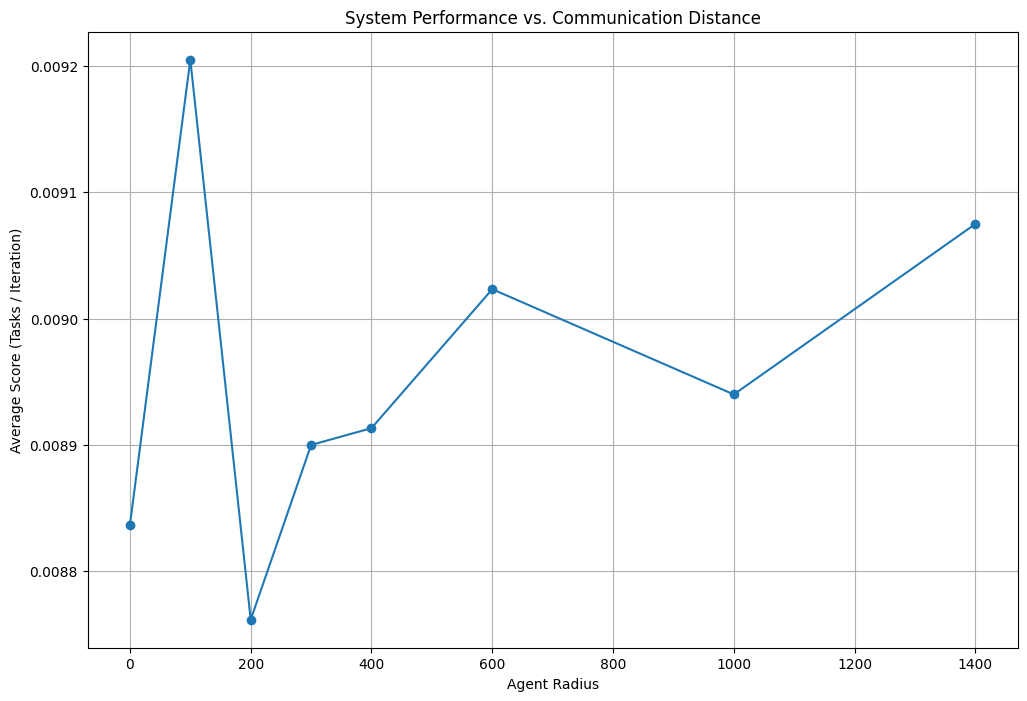

In [ ]:
social_base_params = {
    'ENV_SIZE': (1000, 1000),
    'task_count': 2,
    'task_capacity': 3,
    'task_radius': 50,
    'agent_radius': 250, # A default value we will sweep over
    'agent_count': 30,
    'velocity': 25,
    'timeout_callout': 200, # e.g., wait 200 iterations before giving up
    'timeout_respond': 250  # e.g., search for 250 iterations before giving up
}

# Step 2: Create a new agentInit function for the SocialAgent
def socialAgentInit(pos, velocity):
    # This function now pulls the timeout values from the params dictionary
    return SocialAgent(
        pos, 
        social_base_params['ENV_SIZE'], 
        social_base_params['task_radius'], 
        social_base_params['agent_radius'], 
        social_base_params['timeout_callout'],
        social_base_params['timeout_respond'],
        velocity
    )

# Step 3: Create a new SimulationRunner instance for this experiment
social_runner = SimulationRunner(Environment, socialAgentInit, social_base_params)

# Step 4: Define and run the experiment (e.g., for assignment question e)
# We will test performance vs. communication distance (agent_radius)
# Let's use a fixed number of iterations and replications for this test.
# You would ideally use your convergence analysis to find these numbers first.

sweep_parameters = {
    'agent_radius': [0, 100, 200, 300, 400, 600, 1000, 1400],
    'task_capacity': [3],
    'task_count': [2],
    'iterations': [4000] # Fixed simulation length
}

social_runner.run_sweep(
    sweep_params=sweep_parameters,
    replications=100, # A reasonable number of replications
    description="Varying Communication Radius"
)

# Step 5: Plot the results
social_runner.plot(
    x_axis='agent_radius',
    title="System Performance vs. Communication Distance"
)

--- Starting Parameter Sweep: Varying Communication Radius ---


Varying Communication Radius: 100%|██████████| 800/800 [03:40<00:00,  3.63it/s]

--- Sweep Finished ---


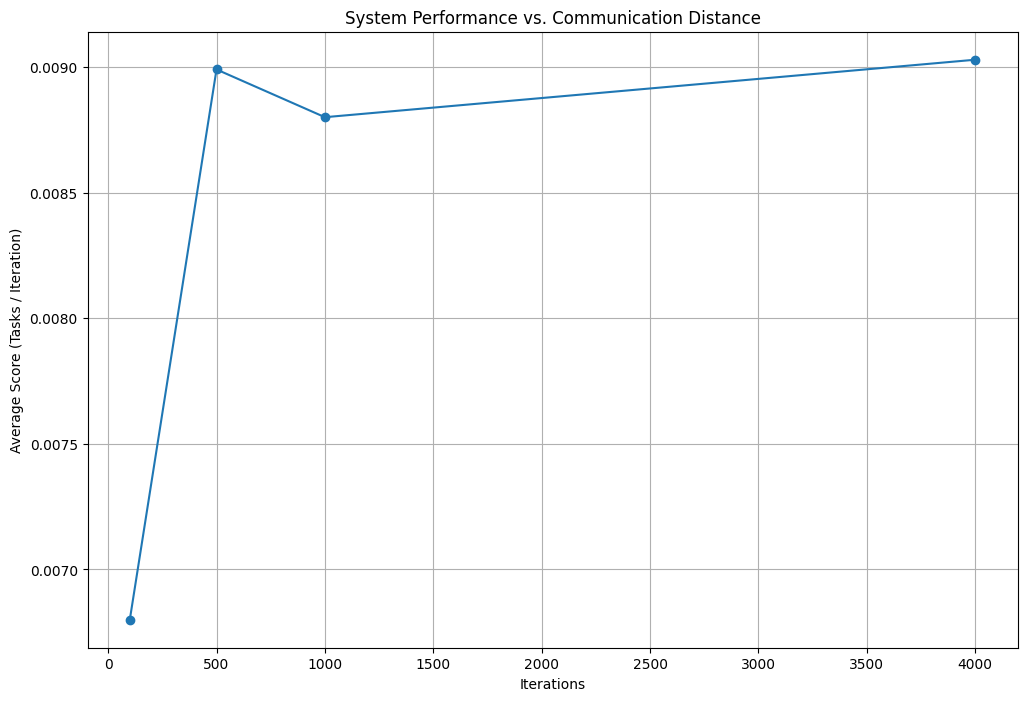

In [105]:
sweep_parameters = {
    'agent_radius': [200],
    'agent_count': [30],
    'task_capacity': [3],
    'task_count': [2],
    'iterations': [100, 500, 1000, 4000] # Fixed simulation length
}

social_runner.run_sweep(
    sweep_params=sweep_parameters,
    replications=200, # A reasonable number of replications
    description="Varying Communication Radius"
)

# Step 5: Plot the results
social_runner.plot(
    x_axis='iterations',
    title="System Performance vs. Communication Distance"
)